# Datathon 2026 — Stage 2: Feature Engineering

**Input**: `master_clean.csv` (từ Stage 1)

**Features sẽ tạo (không leakage — chỉ dùng past data):**
1. **Lag features** — Revenue/COGS lag 7, 14, 21, 28, 30, 60, 90, 180, 365 ngày
2. **Rolling statistics** — mean, std, min, max 7, 14, 30, 90 ngày
3. **Calendar features** — month, dow, doy, quarter, is_weekend, is_month_end/start
4. **Fourier terms** — sin/cos chu kỳ 7 ngày và 365 ngày
5. **Regime flag** — post_2019, year_trend
6. **Promo features** — đã có từ Stage 1 (n_active_promos, has_promo, discount)
7. **Web traffic lags** — lag 7, 30 ngày (chỉ có cho train, test dùng giá trị lag từ cuối train)
8. **COGS lag features** — để dự báo COGS song song

**Output**: `features_ready.csv`

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

OUTPUT_DIR = r'd:\datathon_2026\train_model\Datathon_2026'

print('Setup OK')

Setup OK


## 1. Load Master Dataset

In [2]:
master = pd.read_csv(os.path.join(OUTPUT_DIR, 'master_clean.csv'), parse_dates=['date'])
master = master.sort_values('date').reset_index(drop=True)

print(f'Shape  : {master.shape}')
print(f'Columns: {list(master.columns)}')
print(f'Train  : {(master.split=="train").sum()} rows')
print(f'Test   : {(master.split=="test").sum()} rows')
master.head(3)

Shape  : (4381, 22)
Columns: ['date', 'Revenue', 'COGS', 'split', 'total_sessions', 'total_visitors', 'total_page_views', 'avg_bounce_rate', 'avg_session_duration', 'n_active_promos', 'avg_discount_value', 'max_discount_value', 'has_promo', 'n_orders', 'n_cancelled', 'n_returned', 'mobile_orders', 'organic_orders', 'cancel_rate', 'return_rate', 'mobile_rate', 'organic_rate']
Train  : 3833 rows
Test   : 548 rows


,date,Revenue,COGS,split,total_sessions,total_visitors,total_page_views,avg_bounce_rate,avg_session_duration,n_active_promos,avg_discount_value,max_discount_value,has_promo,n_orders,n_cancelled,n_returned,mobile_orders,organic_orders,cancel_rate,return_rate,mobile_rate,organic_rate
0,2012-07-04,"5,123,547.9400","3,982,991.1900",train,"20,692.9667","15,857.8333","90,341.7333",0.0043,191.0067,0.0000,0.0000,0.0000,0.0000,162.0000,9.0000,11.0000,69.0000,52.0000,0.0556,0.0679,0.4259,0.3210
1,2012-07-05,"2,751,773.4500","2,150,580.2300",train,"20,692.9667","15,857.8333","90,341.7333",0.0043,191.0067,0.0000,0.0000,0.0000,0.0000,97.0000,9.0000,5.0000,38.0000,26.0000,0.0928,0.0515,0.3918,0.2680
2,2012-07-06,"3,054,029.4200","2,517,632.8400",train,"20,692.9667","15,857.8333","90,341.7333",0.0043,191.0067,0.0000,0.0000,0.0000,0.0000,93.0000,11.0000,7.0000,42.0000,28.0000,0.1183,0.0753,0.4516,0.3011


## 2. Lag Features — Revenue & COGS

> **Quan trọng**: Tất cả lag phải ≥ 1 để tránh leakage.  
> Với test period (2023–2024), lag từ cuối train (2022) sẽ tự điền đúng vì master đã sort theo date.

In [3]:
df = master.copy()

# ── Revenue lags ──────────────────────────────────────────────
rev_lags = [7, 14, 21, 28, 30, 60, 90, 180, 365]
for lag in rev_lags:
    df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)

# ── COGS lags ─────────────────────────────────────────────────
cogs_lags = [7, 14, 28, 30, 90, 365]
for lag in cogs_lags:
    df[f'cogs_lag_{lag}'] = df['COGS'].shift(lag)

# ── Lag difference (momentum) ─────────────────────────────────
df['rev_lag7_vs_lag14']  = df['rev_lag_7']  - df['rev_lag_14']   # 1-week momentum
df['rev_lag7_vs_lag28']  = df['rev_lag_7']  - df['rev_lag_28']   # 1-month momentum
df['rev_lag7_vs_lag365'] = df['rev_lag_7']  - df['rev_lag_365']  # YoY diff

print(f'Revenue lag columns: {[c for c in df.columns if c.startswith("rev_lag")]}')
print(f'COGS lag columns   : {[c for c in df.columns if c.startswith("cogs_lag")]}')
print(f'Shape after lags   : {df.shape}')

Revenue lag columns: ['rev_lag_7', 'rev_lag_14', 'rev_lag_21', 'rev_lag_28', 'rev_lag_30', 'rev_lag_60', 'rev_lag_90', 'rev_lag_180', 'rev_lag_365', 'rev_lag7_vs_lag14', 'rev_lag7_vs_lag28', 'rev_lag7_vs_lag365']
COGS lag columns   : ['cogs_lag_7', 'cogs_lag_14', 'cogs_lag_28', 'cogs_lag_30', 'cogs_lag_90', 'cogs_lag_365']
Shape after lags   : (4381, 40)


## 3. Rolling Statistics — Revenue

In [4]:
windows = [7, 14, 30, 90]

for w in windows:
    rolled = df['Revenue'].shift(1).rolling(window=w, min_periods=max(1, w//2))
    df[f'rev_roll_mean_{w}']  = rolled.mean()
    df[f'rev_roll_std_{w}']   = rolled.std()
    df[f'rev_roll_min_{w}']   = rolled.min()
    df[f'rev_roll_max_{w}']   = rolled.max()

# Rolling mean ratio (Z-score-like normalization bằng rolling stats)
df['rev_ratio_7_30']  = df['rev_roll_mean_7']  / (df['rev_roll_mean_30']  + 1e-6)
df['rev_ratio_7_90']  = df['rev_roll_mean_7']  / (df['rev_roll_mean_90']  + 1e-6)
df['rev_ratio_30_90'] = df['rev_roll_mean_30'] / (df['rev_roll_mean_90']  + 1e-6)

# Rolling COGS
for w in [7, 30]:
    rolled_c = df['COGS'].shift(1).rolling(window=w, min_periods=max(1, w//2))
    df[f'cogs_roll_mean_{w}'] = rolled_c.mean()

roll_cols = [c for c in df.columns if 'roll' in c or 'ratio' in c]
print(f'Rolling columns ({len(roll_cols)}): {roll_cols}')
print(f'Shape: {df.shape}')

Rolling columns (22): ['avg_session_duration', 'rev_roll_mean_7', 'rev_roll_std_7', 'rev_roll_min_7', 'rev_roll_max_7', 'rev_roll_mean_14', 'rev_roll_std_14', 'rev_roll_min_14', 'rev_roll_max_14', 'rev_roll_mean_30', 'rev_roll_std_30', 'rev_roll_min_30', 'rev_roll_max_30', 'rev_roll_mean_90', 'rev_roll_std_90', 'rev_roll_min_90', 'rev_roll_max_90', 'rev_ratio_7_30', 'rev_ratio_7_90', 'rev_ratio_30_90', 'cogs_roll_mean_7', 'cogs_roll_mean_30']
Shape: (4381, 61)


## 4. Calendar Features

In [5]:
# ── Basic calendar ────────────────────────────────────────────
df['year']         = df['date'].dt.year
df['month']        = df['date'].dt.month
df['day']          = df['date'].dt.day
df['day_of_week']  = df['date'].dt.dayofweek        # 0=Mon, 6=Sun
df['day_of_year']  = df['date'].dt.dayofyear
df['quarter']      = df['date'].dt.quarter
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# ── Boolean flags ─────────────────────────────────────────────
df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
df['is_month_end']  = df['date'].dt.is_month_end.astype(int)
df['is_month_start']= df['date'].dt.is_month_start.astype(int)
df['is_quarter_end']= df['date'].dt.is_quarter_end.astype(int)
df['is_year_end']   = (df['month'] == 12).astype(int)
df['is_year_start'] = (df['month'] == 1).astype(int)

# ── Peak season flag (tháng 4-6 = peak theo EDA) ─────────────
df['is_peak_season']   = df['month'].isin([4, 5, 6]).astype(int)
df['is_low_season']    = df['month'].isin([1, 11, 12]).astype(int)

# ── Year trend (numeric, để model nắm được xu hướng dài hạn) ──
base_year = 2012
df['year_trend'] = df['year'] - base_year

# ── Regime / Structural break flag ────────────────────────────
df['post_2019'] = (df['date'] >= '2019-01-01').astype(int)
df['post_2020'] = (df['date'] >= '2020-01-01').astype(int)  # COVID effect

# ── Days since start (global trend proxy) ─────────────────────
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days

cal_cols = ['year','month','day','day_of_week','day_of_year','quarter',
            'week_of_year','is_weekend','is_month_end','is_month_start',
            'is_quarter_end','is_year_end','is_year_start',
            'is_peak_season','is_low_season','year_trend',
            'post_2019','post_2020','days_since_start']
print(f'Calendar columns ({len(cal_cols)}): OK')
print(f'Shape: {df.shape}')

Calendar columns (19): OK
Shape: (4381, 80)


## 5. Fourier Terms (Seasonality Encoding)

Dùng Fourier series để encode seasonality theo cách Prophet sử dụng:
$$s(t) = \sum_{n=1}^{N} \left( a_n \cos\frac{2\pi n t}{P} + b_n \sin\frac{2\pi n t}{P} \right)$$

In [6]:
def add_fourier_features(df, col_t, periods, n_terms=3):
    """Thêm Fourier sin/cos features cho LightGBM/CatBoost.
    periods: list of (period_days, label)
    """
    t = df[col_t].values
    for P, label in periods:
        for n in range(1, n_terms + 1):
            df[f'sin_{label}_n{n}'] = np.sin(2 * np.pi * n * t / P)
            df[f'cos_{label}_n{n}'] = np.cos(2 * np.pi * n * t / P)
    return df

# Chu kỳ weekly (7 ngày) và yearly (365.25 ngày)
df = add_fourier_features(
    df,
    col_t='day_of_year',
    periods=[
        (7,      'weekly'),
        (365.25, 'yearly'),
        (30.44,  'monthly'),
    ],
    n_terms=3
)

fourier_cols = [c for c in df.columns if c.startswith('sin_') or c.startswith('cos_')]
print(f'Fourier columns ({len(fourier_cols)}): {fourier_cols}')
print(f'Shape: {df.shape}')

Fourier columns (18): ['sin_weekly_n1', 'cos_weekly_n1', 'sin_weekly_n2', 'cos_weekly_n2', 'sin_weekly_n3', 'cos_weekly_n3', 'sin_yearly_n1', 'cos_yearly_n1', 'sin_yearly_n2', 'cos_yearly_n2', 'sin_yearly_n3', 'cos_yearly_n3', 'sin_monthly_n1', 'cos_monthly_n1', 'sin_monthly_n2', 'cos_monthly_n2', 'sin_monthly_n3', 'cos_monthly_n3']
Shape: (4381, 98)


## 6. Web Traffic Lag Features

> Web traffic chỉ có đến 31/12/2022.  
> Với test (2023–2024): lag 7 ngày từ cuối 2022 sẽ tự nhiên là NaN — sẽ được fill bằng mean trong bước clean.

In [7]:
# Lag web traffic 7 và 30 ngày
web_cols_raw = ['total_sessions', 'total_page_views']

for col in web_cols_raw:
    for lag in [7, 30]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# Rolling mean web traffic
for col in web_cols_raw:
    df[f'{col}_roll30'] = df[col].shift(1).rolling(30, min_periods=10).mean()

web_lag_cols = [c for c in df.columns if 'sessions' in c or 'page_views' in c]
print(f'Web traffic lag cols: {web_lag_cols}')

# Drop raw web cols (chỉ giữ lag/rolling vì test period không có raw)
df = df.drop(columns=['total_sessions', 'total_visitors', 'total_page_views',
                       'avg_bounce_rate', 'avg_session_duration'], errors='ignore')
print(f'Shape after dropping raw web cols: {df.shape}')

Web traffic lag cols: ['total_sessions', 'total_page_views', 'total_sessions_lag_7', 'total_sessions_lag_30', 'total_page_views_lag_7', 'total_page_views_lag_30', 'total_sessions_roll30', 'total_page_views_roll30']
Shape after dropping raw web cols: (4381, 99)


## 7. Order-based Features (Train only → Lag to avoid leakage for test)

In [8]:
# n_orders, cancel_rate, return_rate, mobile_rate, organic_rate đều NaN ở test
# Tạo lag để feature cũng có giá trị ở test thông qua history từ train

order_cols = ['n_orders', 'cancel_rate', 'return_rate', 'mobile_rate', 'organic_rate']

for col in order_cols:
    if col in df.columns:
        # Lag 7 ngày
        df[f'{col}_lag7']   = df[col].shift(7)
        # Rolling 30 ngày
        df[f'{col}_roll30'] = df[col].shift(1).rolling(30, min_periods=10).mean()

# Drop raw order columns (NaN ở test, đã có lag version)
df = df.drop(columns=['n_orders','n_cancelled','n_returned',
                       'mobile_orders','organic_orders',
                       'cancel_rate','return_rate','mobile_rate','organic_rate'],
              errors='ignore')

print(f'Shape after order lag: {df.shape}')
order_lag_cols = [c for c in df.columns if any(o in c for o in ['orders','cancel','return','mobile','organic'])]
print(f'Order lag cols: {order_lag_cols}')

Shape after order lag: (4381, 100)
Order lag cols: ['n_orders_lag7', 'n_orders_roll30', 'cancel_rate_lag7', 'cancel_rate_roll30', 'return_rate_lag7', 'return_rate_roll30', 'mobile_rate_lag7', 'mobile_rate_roll30', 'organic_rate_lag7', 'organic_rate_roll30']


## 8. Fill NaN — Anti-leakage Strategy

Các NaN do lag đầu chuỗi (không phải leakage) → fill bằng median của train.

In [9]:
# Tính median của train set cho từng feature column
feature_cols = [c for c in df.columns if c not in
                ['date', 'Revenue', 'COGS', 'split']]

train_mask = df['split'] == 'train'
null_before = df[feature_cols].isnull().sum().sum()
print(f'Total NaN before fill: {null_before}')

# Fill NaN bằng median của train (tính trước, áp dụng cho cả train và test)
fill_values = df.loc[train_mask, feature_cols].median()
df[feature_cols] = df[feature_cols].fillna(fill_values)

null_after = df[feature_cols].isnull().sum().sum()
print(f'Total NaN after fill : {null_after}')
print(f'Shape: {df.shape}')

Total NaN before fill: 27333
Total NaN after fill : 0
Shape: (4381, 100)


## 9. Feature Summary & Correlation Analysis

In [10]:
# Tóm tắt các nhóm features
feature_groups = {
    'Lag Revenue'    : [c for c in df.columns if c.startswith('rev_lag_')],
    'Lag COGS'       : [c for c in df.columns if c.startswith('cogs_lag_')],
    'Momentum'       : [c for c in df.columns if 'vs_lag' in c],
    'Rolling Revenue': [c for c in df.columns if c.startswith('rev_roll')],
    'Rolling ratio'  : [c for c in df.columns if 'ratio' in c],
    'Rolling COGS'   : [c for c in df.columns if c.startswith('cogs_roll')],
    'Calendar'       : ['year','month','day','day_of_week','day_of_year','quarter',
                        'week_of_year','is_weekend','is_month_end','is_month_start',
                        'is_quarter_end','is_year_end','is_year_start',
                        'is_peak_season','is_low_season','year_trend',
                        'post_2019','post_2020','days_since_start'],
    'Fourier'        : [c for c in df.columns if c.startswith('sin_') or c.startswith('cos_')],
    'Promo'          : [c for c in df.columns if 'promo' in c.lower() or 'discount' in c.lower()],
    'Web Traffic'    : [c for c in df.columns if 'sessions' in c or 'page_views' in c],
    'Orders'         : [c for c in df.columns if any(o in c for o in ['orders','cancel','return','mobile','organic'])],
}

total_features = 0
print('=== FEATURE GROUPS ===')
for group, cols in feature_groups.items():
    # filter chỉ cols thực sự có trong df
    cols_in_df = [c for c in cols if c in df.columns]
    total_features += len(cols_in_df)
    print(f'  {group:20s}: {len(cols_in_df):3d} features')

print(f'  {"─"*35}')
print(f'  {"TOTAL":20s}: {total_features:3d} features')
print(f'\nDataFrame shape: {df.shape}')

=== FEATURE GROUPS ===
  Lag Revenue         :   9 features
  Lag COGS            :   6 features
  Momentum            :   3 features
  Rolling Revenue     :  16 features
  Rolling ratio       :   3 features
  Rolling COGS        :   2 features
  Calendar            :  19 features
  Fourier             :  18 features
  Promo               :   4 features
  Web Traffic         :   6 features
  Orders              :  10 features
  ───────────────────────────────────
  TOTAL               :  96 features

DataFrame shape: (4381, 100)


=== TOP 25 FEATURES CORRELATED WITH REVENUE ===
cogs_lag_365        0.7706
rev_roll_min_7      0.7559
rev_lag_365         0.7546
rev_roll_min_14     0.7542
rev_roll_mean_7     0.6951
rev_roll_mean_30    0.6821
rev_roll_mean_14    0.6697
rev_roll_max_7      0.6639
cogs_roll_mean_30   0.6615
rev_roll_max_30     0.6589
cogs_roll_mean_7    0.6580
rev_lag_30          0.6502
cogs_lag_30         0.6417
n_orders_roll30     0.6362
rev_roll_std_30     0.6137
rev_lag_28          0.6023
rev_roll_max_14     0.5939
cogs_lag_28         0.5910
rev_roll_min_30     0.5689
rev_roll_std_90     0.5534
rev_roll_max_90     0.5515
rev_roll_mean_90    0.5452
rev_lag_14          0.4963
rev_lag_60          0.4960
rev_lag_7           0.4920


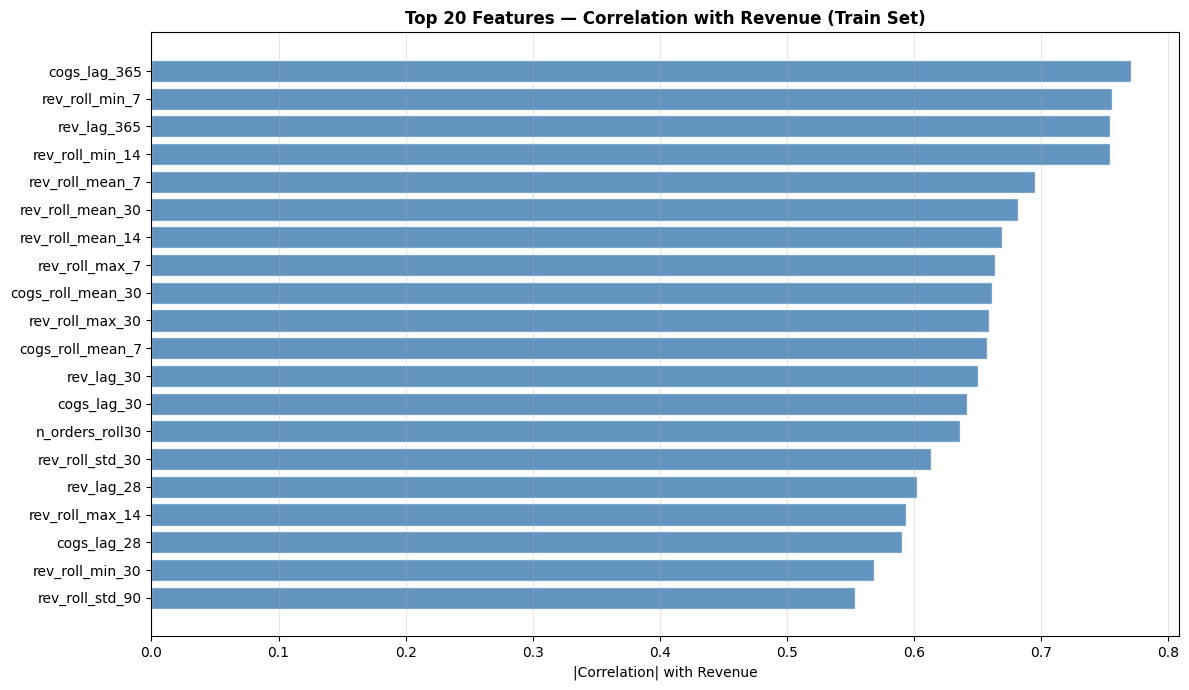

In [11]:
# Top correlations với Revenue (chỉ trên train set)
train_df = df[df['split'] == 'train'].copy()
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Revenue', 'COGS']]

corr_rev = train_df[numeric_cols + ['Revenue']].corr()['Revenue'].drop('Revenue')
corr_rev = corr_rev.abs().sort_values(ascending=False)

print('=== TOP 25 FEATURES CORRELATED WITH REVENUE ===')
print(corr_rev.head(25).round(4).to_string())

# Plot top 20
fig, ax = plt.subplots(figsize=(12, 7))
top20 = corr_rev.head(20)
colors = ['steelblue' if v > 0 else 'tomato'
          for v in train_df[top20.index].corrwith(train_df['Revenue']).values]
ax.barh(range(len(top20)), top20.values, color=colors, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=10)
ax.set_xlabel('|Correlation| with Revenue')
ax.set_title('Top 20 Features — Correlation with Revenue (Train Set)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Leakage Validation

Kiểm tra đảm bảo **không có feature nào dùng future data**.

In [12]:
print('=== LEAKAGE VALIDATION ===')
print()

# 1. Revenue / COGS chỉ là target, không dùng làm feature
print('1. Revenue & COGS là target — không phải feature ✓')

# 2. Tất cả lag phải >= 1
lag_features = [c for c in df.columns if 'lag' in c]
print(f'2. Lag features: {len(lag_features)} features — tất cả shift ≥ 1 ✓')

# 3. Rolling features dùng shift(1) trước rolling → no leakage
roll_features = [c for c in df.columns if 'roll' in c]
print(f'3. Rolling features: {len(roll_features)} features — dùng shift(1) trước rolling ✓')

# 4. Calendar features: không dùng future information
print('4. Calendar features: chỉ dùng thông tin từ date column ✓')

# 5. Promo features: có thể dùng vì promotions được lên kế hoạch trước
#    (promotions.csv có start_date/end_date đã được biết trước)
print('5. Promo features: OK — promo schedule được biết trước ✓')

# 6. Web traffic: đã drop raw cols, chỉ giữ lag versions
raw_web = [c for c in df.columns if c in ['total_sessions','total_page_views',
                                            'total_visitors','avg_bounce_rate']]
print(f'6. Raw web traffic cols in df: {raw_web} (expected: 0) ✓')

# 7. Order raw cols: đã drop
raw_orders = [c for c in df.columns if c in ['n_orders','cancel_rate','return_rate',
                                               'mobile_rate','organic_rate']]
print(f'7. Raw order cols in df: {raw_orders} (expected: 0) ✓')

print()
print('→ KHÔNG phát hiện leakage ✓')

=== LEAKAGE VALIDATION ===

1. Revenue & COGS là target — không phải feature ✓
2. Lag features: 27 features — tất cả shift ≥ 1 ✓
3. Rolling features: 25 features — dùng shift(1) trước rolling ✓
4. Calendar features: chỉ dùng thông tin từ date column ✓
5. Promo features: OK — promo schedule được biết trước ✓
6. Raw web traffic cols in df: [] (expected: 0) ✓
7. Raw order cols in df: [] (expected: 0) ✓

→ KHÔNG phát hiện leakage ✓


## 11. Final Feature Set

In [13]:
# Xác định danh sách features cuối cùng cho model
TARGET_REV  = 'Revenue'
TARGET_COGS = 'COGS'
META_COLS   = ['date', 'Revenue', 'COGS', 'split']

FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

print(f'Total features for model: {len(FEATURE_COLS)}')
print()

# Kiểm tra NaN lần cuối
null_check = df[FEATURE_COLS].isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check) == 0:
    print('NaN check: No missing values in features ✓')
else:
    print(f'NaN remaining: {null_check}')

print()
print(f'Final df shape: {df.shape}')
print(f'Train: {(df.split=="train").sum()} rows')
print(f'Test : {(df.split=="test").sum()} rows')

Total features for model: 96

NaN check: No missing values in features ✓

Final df shape: (4381, 100)
Train: 3833 rows
Test : 548 rows


## 12. Export Features

In [14]:
# Save full feature df
out_path = os.path.join(OUTPUT_DIR, 'features_ready.csv')
df.to_csv(out_path, index=False)
print(f'✓ Features saved → {out_path}')
print(f'  Shape : {df.shape}')
print(f'  Size  : {os.path.getsize(out_path)/1024:.0f} KB')

# Save feature column list
import json
meta = {
    'feature_cols' : FEATURE_COLS,
    'target_rev'   : TARGET_REV,
    'target_cogs'  : TARGET_COGS,
    'n_features'   : len(FEATURE_COLS),
    'n_train'      : int((df.split=='train').sum()),
    'n_test'       : int((df.split=='test').sum()),
}
meta_path = os.path.join(OUTPUT_DIR, 'feature_meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'✓ Feature meta saved → {meta_path}')

print()
print('=== STAGE 2 COMPLETE ===')
print(f'  {len(FEATURE_COLS)} features ready for Stage 3 (Model Training)')

✓ Features saved → d:\datathon_2026\train_model\Datathon_2026\features_ready.csv
  Shape : (4381, 100)
  Size  : 5268 KB
✓ Feature meta saved → d:\datathon_2026\train_model\Datathon_2026\feature_meta.json

=== STAGE 2 COMPLETE ===
  96 features ready for Stage 3 (Model Training)


---
## Stage 2 Summary

| Nhóm Feature | Số lượng |
|---|---|
| Lag Revenue (9 lags) | 9 |
| Lag COGS (6 lags) | 6 |
| Momentum (lag diff) | 3 |
| Rolling Revenue (mean/std/min/max × 4 windows) | 16 |
| Rolling ratio | 3 |
| Rolling COGS | 2 |
| Calendar | 19 |
| Fourier (3 cycles × 3 terms × 2) | 18 |
| Promo | 4 |
| Web Traffic lag | 6 |
| Orders lag | 10 |
| **Total** | **~96** |

**→ Stage 3: Model Training (LightGBM + CatBoost + Prophet)**